# Loading Dataset 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format/A_Z Handwritten Data.csv")

# Data Analysis

In [3]:
df.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
print(df.shape)
print(df["0"].unique())

(372450, 785)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


In [5]:
df = df.rename(columns = {"0":"output"})

In [6]:
word_dict = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X', 24:'Y',25:'Z'}

In [7]:
df["output"].value_counts()

output
14    57825
18    48419
20    29008
2     23409
19    22495
15    19341
13    19010
0     13869
12    12336
11    11586
17    11566
4     11440
24    10859
22    10784
3     10134
1      8668
9      8493
7      7218
23     6272
25     6076
16     5812
6      5762
10     5603
21     4182
5      1163
8      1120
Name: count, dtype: int64

In [8]:
X = df.drop(columns = "output",axis = 1)
y = df["output"]

In [9]:
y = y.astype(int)

# Data Visualisation

In [10]:
import matplotlib.pyplot as plt 
import seaborn as sns 

In [11]:
alphabet_counts = y.value_counts().sort_index()

In [12]:
alphabet_counts.index = alphabet_counts.index.map(word_dict)

/tmp/ipykernel_23/2387498537.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=alphabet_counts.index, y=alphabet_counts.values, palette='viridis')


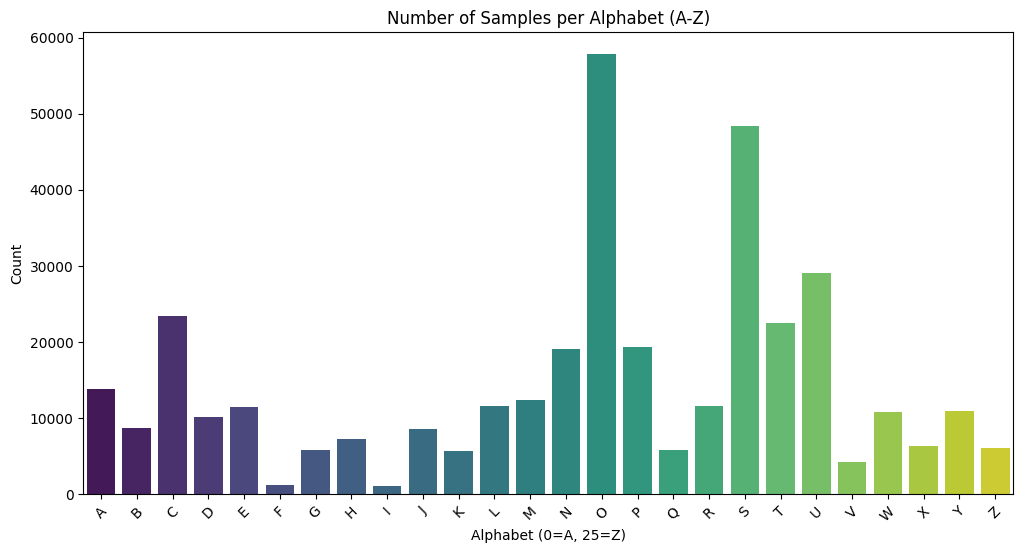

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(x=alphabet_counts.index, y=alphabet_counts.values, palette='viridis')
plt.title("Number of Samples per Alphabet (A-Z)")
plt.xlabel("Alphabet (0=A, 25=Z)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

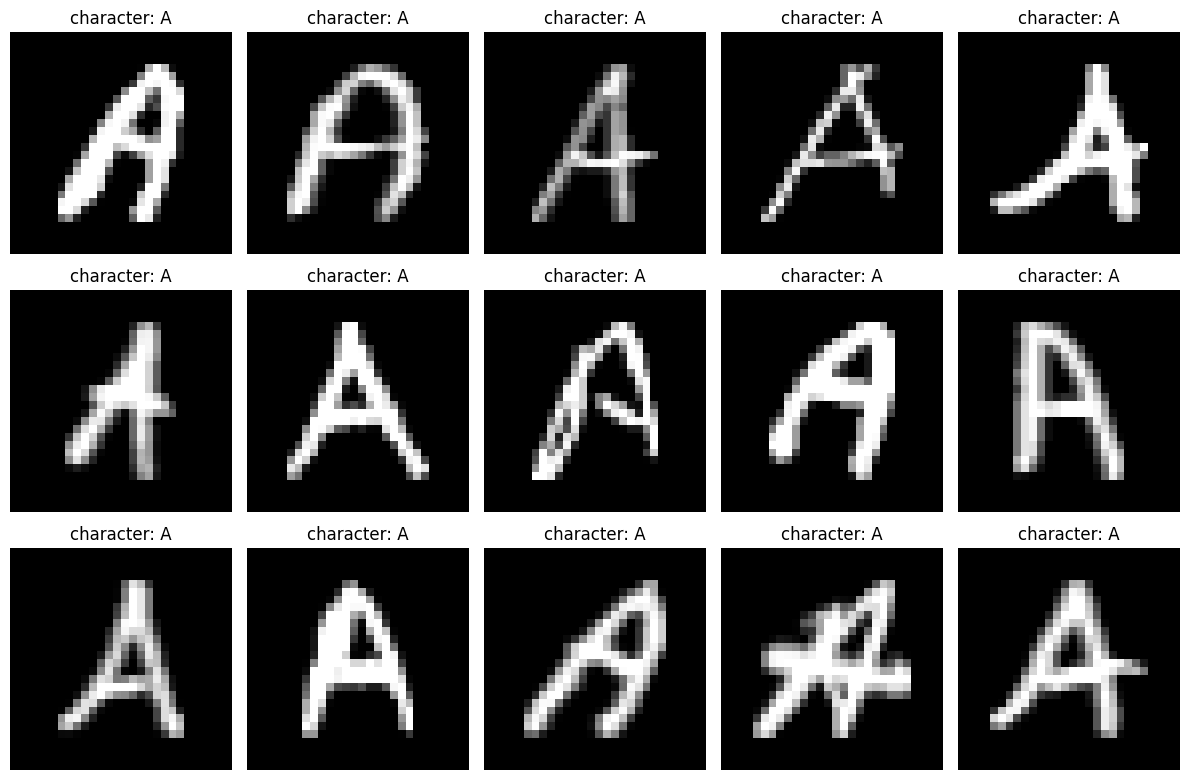

In [14]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    img = X.iloc[i].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"character: {chr(65 + int(y[i]))}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# Machine Learning Model training

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X = X/255.0

# splitting data 

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (297960, 784)
Test data shape: (74490, 784)


# Model building 

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [19]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Model Evaulation

In [20]:
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Results:")
print(f"Accuracy: {rf_accuracy:.4f}")

Random Forest Results:
Accuracy: 0.9876


# classification report 

In [21]:
classification_report(y_test, rf_pred, target_names=list(word_dict.values()))

'              precision    recall  f1-score   support\n\n           A       0.97      0.99      0.98      2806\n           B       0.98      0.98      0.98      1673\n           C       0.99      0.99      0.99      4742\n           D       0.98      0.96      0.97      2044\n           E       0.99      0.98      0.99      2214\n           F       1.00      0.94      0.97       231\n           G       0.99      0.97      0.98      1183\n           H       0.98      0.96      0.97      1466\n           I       1.00      0.96      0.98       237\n           J       0.98      0.97      0.98      1668\n           K       0.98      0.96      0.97      1132\n           L       1.00      1.00      1.00      2319\n           M       0.98      0.97      0.98      2487\n           N       0.98      0.99      0.98      3756\n           O       0.99      1.00      0.99     11629\n           P       0.99      0.99      0.99      3868\n           Q       0.99      0.95      0.97      1159\n       

# Prediction 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

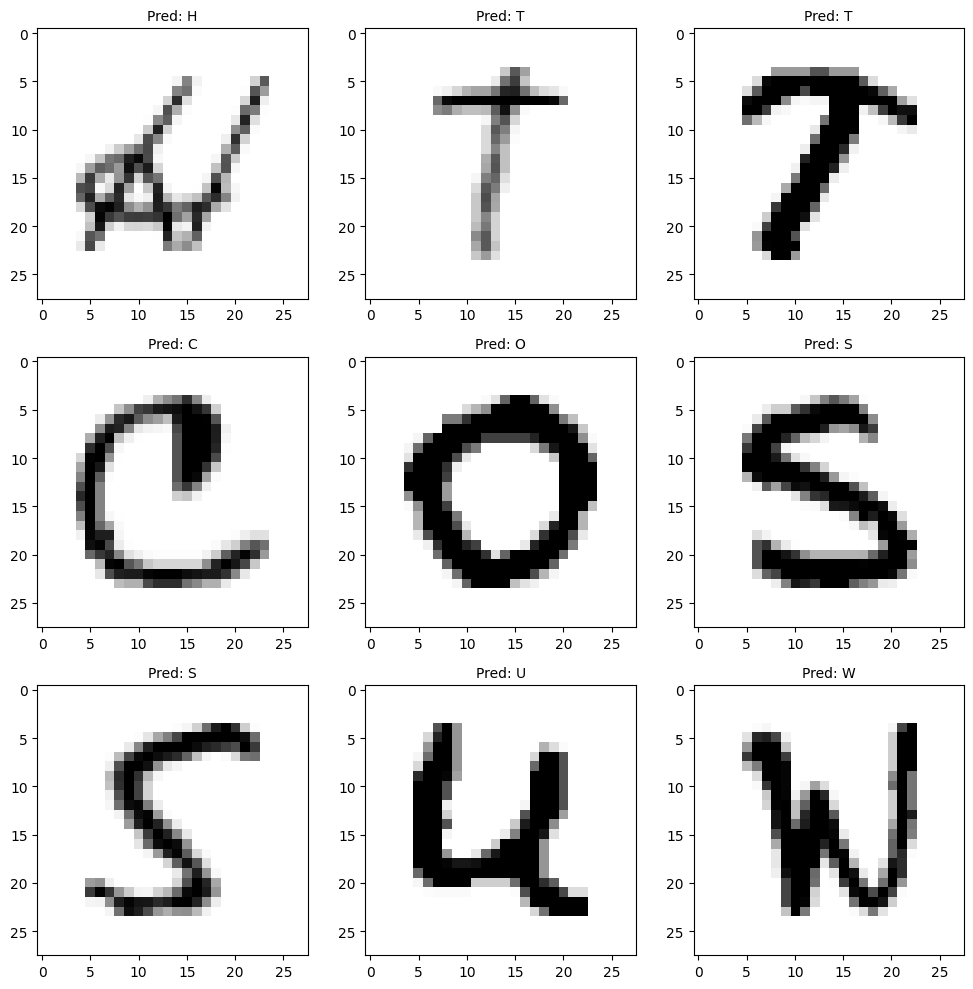

In [22]:
sample_indices = np.random.choice(len(X_test), 9, replace=False)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = X_test.iloc[sample_indices[i]].values.reshape(28, 28)
    true_label = word_dict[y_test.iloc[sample_indices[i]]]

    rf_pred = word_dict[rf_model.predict([X_test.iloc[sample_indices[i]]])[0]]

    ax.imshow(img, cmap='Greys')
    ax.set_title(f"Pred: {rf_pred}", fontsize=10)

plt.tight_layout()
plt.show()

# CNN 

In [23]:
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.utils import to_categorical

2026-06-12 15:09:02.527915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781276943.086306      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781276943.203625      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781276944.453592      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781276944.453622      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781276944.453624      23 computation_placer.cc:177] computation placer alr

In [24]:
X = X.values.reshape(-1, 28, 28, 1)
y = to_categorical(y, num_classes=26)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
     

In [26]:
model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(26, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781276966.846552      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781276966.852445      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [27]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
     

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test))

Epoch 1/10


I0000 00:00:1781276972.740026      71 service.cc:152] XLA service 0x7fc7180423b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781276972.740071      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781276972.740075      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781276973.202724      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


  56/4656 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.2458 - loss: 2.7256

I0000 00:00:1781276977.202391      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4656/4656 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9228 - loss: 0.2712 - val_accuracy: 0.9808 - val_loss: 0.0698
Epoch 2/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9670 - loss: 0.1194 - val_accuracy: 0.9850 - val_loss: 0.0536
Epoch 3/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9749 - loss: 0.0910 - val_accuracy: 0.9873 - val_loss: 0.0473
Epoch 4/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9788 - loss: 0.0757 - val_accuracy: 0.9888 - val_loss: 0.0417
Epoch 5/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9811 - loss: 0.0660 - val_accuracy: 0.9903 - val_loss: 0.0372
Epoch 6/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9831 - loss: 0.0578 - val_accuracy: 0.9898 - val_loss: 0.0386
Epoch 7/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9848 - loss: 0.0519 - val_accuracy: 0.9903 - val_loss: 0.0367
Epoch 8/10
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9856 - loss: 0.0486 - val

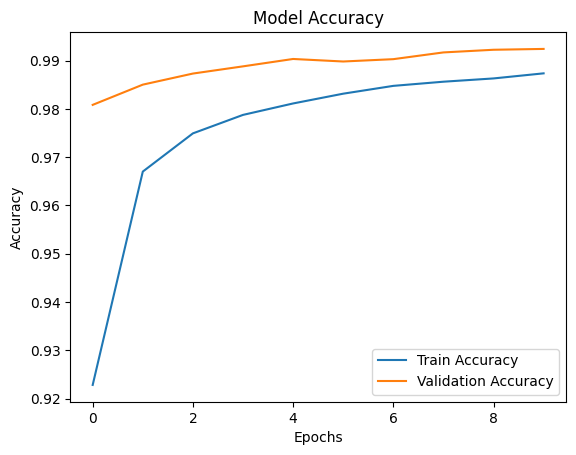

In [30]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

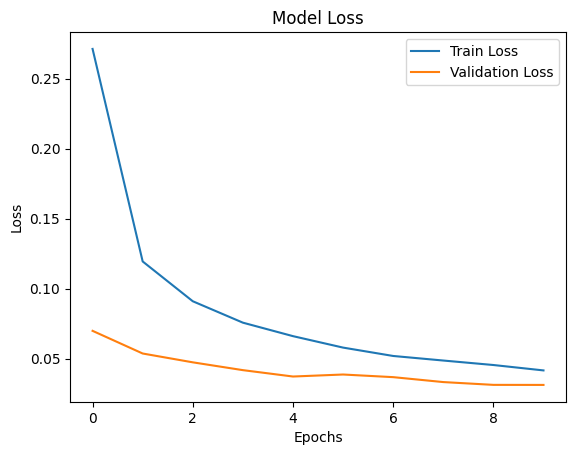

In [31]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Exporting CNN model

In [32]:
from joblib import dump
dump(model, 'cnn_az_handwritten.joblib', compress=3)

['cnn_az_handwritten.joblib']

In [33]:
model.save('cnn_az_handwritten.h5')
from google.colab import files
files.download('cnn_az_handwritten.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>